✅ Gráfica limpia generada en 'work/grafica_vibrato_final.png'


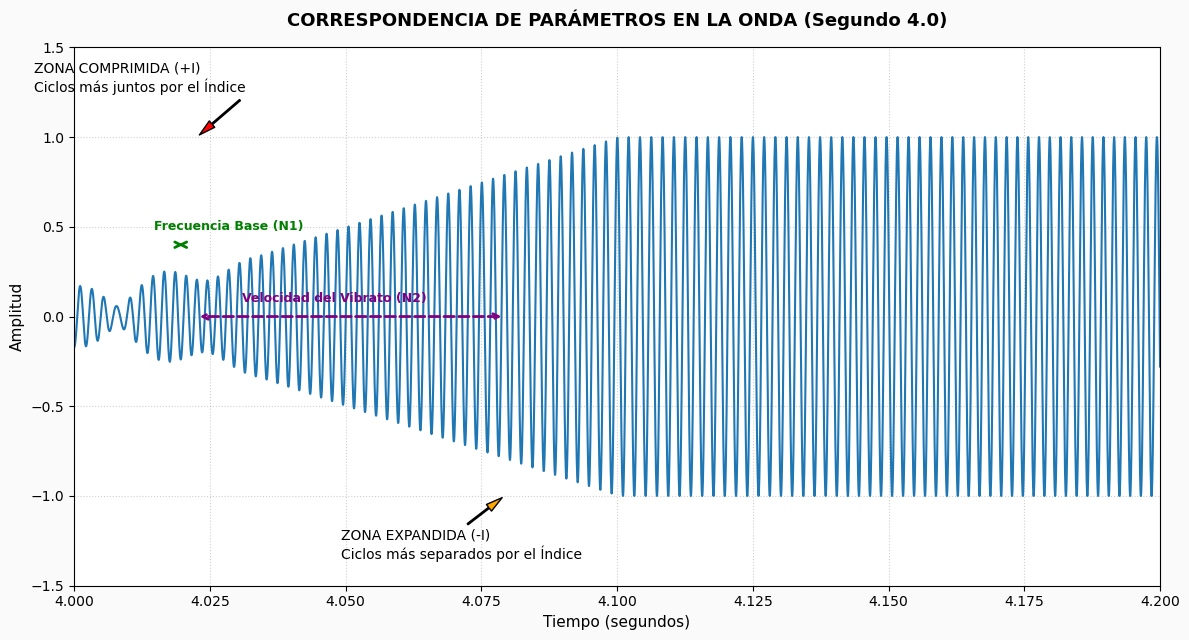

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.signal import find_peaks

# 1. CARGAR TU AUDIO REAL
try:
    sampling_rate, data = wavfile.read('work/vibrato.wav')
except FileNotFoundError:
    print("❌ Error: No se encuentra 'work/vibrato.wav'. Generalo antes.")
    exit()

if len(data.shape) > 1:
    data = data[:, 0]
data = data / np.max(np.abs(data))

# 2. SEGUNDO 4.0 A 4.2 (Zoom perfecto para ver los ciclos)
inicio_seg = 4.0  
fin_seg = 4.2  

sample_inicio = int(inicio_seg * sampling_rate)
sample_fin = int(fin_seg * sampling_rate)

senal_zoom = data[sample_inicio:sample_fin]
tiempo = np.linspace(inicio_seg, fin_seg, len(senal_zoom))

# 3. ENCONTRAR DÓNDE SE APRIETAN Y SE SEPARAN LOS CICLOS REALES
picos, _ = find_peaks(senal_zoom, distance=int(sampling_rate*0.001), height=0.2)
distancias = np.diff(picos)

# Buscar el ciclo más apretado y el más estirado
idx_comprimido = picos[np.argmin(distancias)]
t_comprimido = tiempo[idx_comprimido]

idx_expandido = picos[np.argmax(distancias)]
t_expandido = tiempo[idx_expandido]

# 4. PINTAR LA GRÁFICA ÚNICA
plt.figure(figsize=(12, 6.5), facecolor='#fafafa')
plt.plot(tiempo, senal_zoom, color='#1f77b4', linewidth=1.5, label='Tu onda real')

plt.title('CORRESPONDENCIA DE PARÁMETROS EN LA ONDA (Segundo 4.0)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Tiempo (segundos)', fontsize=11)
plt.ylabel('Amplitud', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.xlim(inicio_seg, fin_seg)
plt.ylim(-1.5, 1.5)

# --- PINTAR LAS CORRESPONDENCIAS DE EXAMEN ---

# N1 (Portadora): La distancia estándar entre dos crestas normales
t_pico1 = tiempo[picos[2]]
t_pico2 = tiempo[picos[3]]
plt.annotate('', xy=(t_pico1, 0.4), xytext=(t_pico2, 0.4), arrowprops=dict(arrowstyle='<->', color='green', lw=2))
plt.text((t_pico1+t_pico2)/2 - 0.005, 0.48, 'Frecuencia Base (N1)', color='green', fontweight='bold', fontsize=9)

# I (Índice): Apunta a la zona donde los ciclos se aprietan y se estiran
plt.annotate('ZONA COMPRIMIDA (+I)\nCiclos más juntos por el Índice', 
             xy=(t_comprimido, 1.0), xytext=(t_comprimido - 0.03, 1.25),
             arrowprops=dict(facecolor='red', shrink=0.05, width=1, headwidth=6))

plt.annotate('ZONA EXPANDIDA (-I)\nCiclos más separados por el Índice', 
             xy=(t_expandido, -1.0), xytext=(t_expandido - 0.03, -1.35),
             arrowprops=dict(facecolor='orange', shrink=0.05, width=1, headwidth=6))

# N2 (Moduladora): El tiempo que tarda el vaivén en ir de comprimido a expandido
plt.annotate('', xy=(t_comprimido, 0.0), xytext=(t_expandido, 0.0), arrowprops=dict(arrowstyle='<->', color='purple', lw=2, ls='--'))
plt.text((t_comprimido+t_expandido)/2 - 0.02, 0.08, 'Velocidad del Vibrato (N2)', color='purple', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig('work/grafica_vibrato_final.png', dpi=300)
print("✅ Gráfica limpia generada en 'work/grafica_vibrato_final.png'")
plt.show()